# Polyvore Route A (Notebook, Run All)

按“Run All”从上到下顺序执行：会自动定位数据路径、训练（默认 1 epoch，用于演示）并画出训练曲线。

如果要正式训练，把第 3 个 cell 里的 `epochs` 改大即可。


In [1]:
import argparse
import dataclasses
import os
import random
from typing import Optional
from typing import Sequence
from typing import Tuple

import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms

from polyvore_route_a import SLOT_ORDER
from polyvore_route_a import slot_from_image_path
from polyvore_route_a import sort_outfit_paths
from polyvore_route_a import build_image_index
from polyvore_route_a import open_polyvore_member_text
from polyvore_route_a import parse_cp_line
from polyvore_route_a import CpExample
from polyvore_route_a import load_cp_examples
from polyvore_route_a import CpDataset
from polyvore_route_a import collate_cp
from polyvore_route_a import OutfitCompatModel
from polyvore_route_a import FitbExample
from polyvore_route_a import load_fitb_test_examples
from polyvore_route_a import build_fitb_train_examples
from polyvore_route_a import FitbDataset
from polyvore_route_a import collate_fitb
from polyvore_route_a import evaluate

cp_train_log = ""
fitb_train_log = ""
log_text = ""

def run_train_cp(args: argparse.Namespace) -> None:
    global cp_train_log, log_text
    cp_train_log = ""
    log_text = ""
    log_lines: list[str] = []
    def log(msg: str) -> None:
        print(msg)
        log_lines.append(msg)

    save_best = bool(getattr(args, "save_best", False))
    monitor = str(getattr(args, "early_stop_metric", "auc") or "auc").lower()
    patience = int(getattr(args, "early_stop_patience", 0) or 0)
    min_delta = float(getattr(args, "early_stop_min_delta", 0.0) or 0.0)
    mode = "max" if monitor in {"auc", "acc"} else "min"
    best_score = float("-inf") if mode == "max" else float("inf")
    best_epoch = 0
    best_metrics: dict[str, float] = {}
    best_state: Optional[dict[str, torch.Tensor]] = None
    bad_epochs = 0

    device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
    image_index = build_image_index(args.images_root)
    examples = load_cp_examples(
        polyvore_tar_path=args.polyvore_tar,
        image_index=image_index,
        min_items=args.min_items,
        max_items=args.max_items,
    )
    if len(examples) == 0:
        raise RuntimeError("No usable examples found. Check images_root / min_items.")

    rng = random.Random(args.seed)
    rng.shuffle(examples)
    split = int(len(examples) * (1.0 - args.val_ratio))
    train_ex = examples[:split]
    val_ex = examples[split:]

    train_tfm = transforms.Compose(
        [
            transforms.RandomResizedCrop(args.image_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    val_tfm = transforms.Compose(
        [
            transforms.Resize((args.image_size, args.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    train_ds = CpDataset(train_ex, train_tfm)
    val_ds = CpDataset(val_ex, val_tfm)
    train_loader = DataLoader(
        train_ds,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        collate_fn=collate_cp,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        collate_fn=collate_cp,
    )

    model = OutfitCompatModel(
        backbone_name=args.backbone,
        embed_dim=args.embed_dim,
        freeze_backbone=args.freeze_backbone,
        arch=args.arch,
        lstm_hidden=args.lstm_hidden,
        lstm_layers=args.lstm_layers,
        lstm_dropout=args.lstm_dropout,
    ).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=args.lr, weight_decay=args.weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(1, args.epochs + 1):
        model.train()
        running = 0.0
        seen = 0
        for x, mask, y in train_loader:
            x = x.to(device)
            mask = mask.to(device)
            y = y.to(device)
            opt.zero_grad(set_to_none=True)
            logit = model(x, mask)
            loss = loss_fn(logit, y)
            loss.backward()
            opt.step()
            running += float(loss.item()) * int(y.numel())
            seen += int(y.numel())
        train_loss = running / max(1, seen)
        val_metrics = evaluate(model, val_loader, device)
        log(
            f"epoch={epoch} train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} val_auc={val_metrics['auc']:.4f}"
        )

        score = float(val_metrics.get(monitor, float("nan")))
        if score != score:
            score = float("-inf") if mode == "max" else float("inf")
        improved = best_state is None
        if not improved:
            if mode == "max":
                improved = score > (best_score + min_delta)
            else:
                improved = score < (best_score - min_delta)
        if improved:
            best_score = score
            best_epoch = epoch
            best_metrics = dict(val_metrics)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
            log(f"best epoch={best_epoch} val_loss={best_metrics['loss']:.4f} val_acc={best_metrics['acc']:.4f} val_auc={best_metrics['auc']:.4f}")
        else:
            bad_epochs += 1

        if patience and bad_epochs >= patience:
            log(f"early_stop epoch={epoch} best_epoch={best_epoch} best_{monitor}={best_score:.4f}")
            break

    if args.save_path:
        os.makedirs(os.path.dirname(os.path.abspath(args.save_path)), exist_ok=True)
        args_dict = {k: v for k, v in vars(args).items() if k != "func"}
        state_to_save = best_state if (save_best and best_state is not None) else model.state_dict()
        torch.save(
            {
                "model_state": state_to_save,
                "args": args_dict,
                "best_epoch": best_epoch,
                "best_metrics": best_metrics,
                "early_stop_metric": monitor,
                "best_score": best_score,
            },
            args.save_path,
        )

    cp_train_log = "\n".join(log_lines) + ("\n" if log_lines else "")
    log_text = cp_train_log

def run_train_fitb(args: argparse.Namespace) -> None:
    global fitb_train_log, log_text
    fitb_train_log = ""
    log_text = ""
    log_lines: list[str] = []
    def log(msg: str) -> None:
        print(msg)
        log_lines.append(msg)

    device = torch.device("cuda" if torch.cuda.is_available() and not args.cpu else "cpu")
    image_index = build_image_index(args.images_root)
    examples = build_fitb_train_examples(
        polyvore_tar_path=args.polyvore_tar,
        image_index=image_index,
        num_candidates=args.num_candidates,
        min_items=args.min_items,
        max_items=args.max_items,
        num_samples=args.train_samples,
        seed=args.seed,
    )
    if len(examples) == 0:
        raise RuntimeError("No usable FITB train examples found. Check images_root / min_items.")

    rng = random.Random(args.seed)
    rng.shuffle(examples)
    split = int(len(examples) * (1.0 - args.val_ratio))
    train_ex = examples[:split]
    val_ex = examples[split:]

    train_tfm = transforms.Compose(
        [
            transforms.RandomResizedCrop(args.image_size, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    val_tfm = transforms.Compose(
        [
            transforms.Resize((args.image_size, args.image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    train_ds = FitbDataset(train_ex, train_tfm)
    val_ds = FitbDataset(val_ex, val_tfm)
    train_loader = DataLoader(
        train_ds,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        collate_fn=collate_fitb,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        collate_fn=collate_fitb,
    )

    model = OutfitCompatModel(
        backbone_name=args.backbone,
        embed_dim=args.embed_dim,
        freeze_backbone=args.freeze_backbone,
        arch=args.arch,
        lstm_hidden=args.lstm_hidden,
        lstm_layers=args.lstm_layers,
        lstm_dropout=args.lstm_dropout,
    ).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=args.lr, weight_decay=args.weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, args.epochs + 1):
        model.train()
        running = 0.0
        seen = 0
        for x, mask, target in train_loader:
            b, cands, n, ch, h, w = x.shape
            x = x.to(device).view(b * cands, n, ch, h, w)
            mask = mask.to(device).view(b * cands, n)
            target = target.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x, mask).view(b, cands)
            loss = loss_fn(logits, target)
            loss.backward()
            opt.step()
            running += float(loss.item()) * int(target.numel())
            seen += int(target.numel())
        train_loss = running / max(1, seen)

        model.eval()
        correct = 0
        total = 0
        val_losses: list[float] = []
        with torch.no_grad():
            for x, mask, target in val_loader:
                b, cands, n, ch, h, w = x.shape
                x = x.to(device).view(b * cands, n, ch, h, w)
                mask = mask.to(device).view(b * cands, n)
                target = target.to(device)
                logits = model(x, mask).view(b, cands)
                loss = loss_fn(logits, target)
                val_losses.append(float(loss.item()))
                pred = torch.argmax(logits, dim=1)
                correct += int((pred == target).sum().item())
                total += int(target.numel())
        val_loss = sum(val_losses) / max(1, len(val_losses))
        val_acc = correct / max(1, total)
        log(f"epoch={epoch} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if args.save_path:
        os.makedirs(os.path.dirname(os.path.abspath(args.save_path)), exist_ok=True)
        args_dict = {k: v for k, v in vars(args).items() if k != "func"}
        torch.save({"model_state": model.state_dict(), "args": args_dict}, args.save_path)

    fitb_train_log = "\n".join(log_lines) + ("\n" if log_lines else "")
    log_text = fitb_train_log


In [2]:
from pathlib import Path
from types import SimpleNamespace

cp_train_log = ""
fitb_train_log = ""
log_text = ""

def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "polyvore_route_a_rewrite.ipynb").exists() or (p / "polyvore_route_a.py").exists():
            return p
    raise FileNotFoundError("project root not found")

project_root = find_project_root()
images_root = project_root / "archive" / "Re-PolyVore" / "Re-PolyVore" / "Re-PolyVore"
polyvore_tar = project_root / "polyvore-dataset-master" / "polyvore.tar.gz"

print("project_root=", project_root)
print("images_root=", images_root, "exists=", images_root.exists())
print("polyvore_tar=", polyvore_tar, "exists=", polyvore_tar.exists())
if not images_root.exists():
    raise FileNotFoundError(str(images_root))
if not polyvore_tar.exists():
    raise FileNotFoundError(str(polyvore_tar))

args = SimpleNamespace(
    images_root=str(images_root),
    polyvore_tar=str(polyvore_tar),
    min_items=3,
    max_items=8,
    image_size=224,
    backbone="resnet50",
    embed_dim=256,
    arch="bilstm",
    lstm_hidden=128,
    lstm_layers=1,
    lstm_dropout=0.0,
    freeze_backbone=True,
    epochs=20,
    batch_size=8,
    lr=1e-4,
    weight_decay=1e-4,
    val_ratio=0.2,
    seed=43,
    num_workers=0,
    cpu=False,
    save_best=True,
    early_stop_metric="auc",
    early_stop_patience=3,
    early_stop_min_delta=0.0,
    save_path=str(project_root / "models" / "cp_best_seed43.pth"),
)


project_root= D:\Projects\JupyterProject\COMP7065_GROUP
images_root= D:\Projects\JupyterProject\COMP7065_GROUP\archive\Re-PolyVore\Re-PolyVore\Re-PolyVore exists= True
polyvore_tar= D:\Projects\JupyterProject\COMP7065_GROUP\polyvore-dataset-master\polyvore.tar.gz exists= True


In [3]:
cp_train_log = ""
log_text = ""

run_train_cp(args)

ckpt = torch.load(args.save_path, map_location="cpu", weights_only=False)
print("saved=", args.save_path)
print("best_epoch=", ckpt.get("best_epoch"))
print("best_metrics=", ckpt.get("best_metrics"))


epoch=1 train_loss=0.6039 val_loss=0.5397 val_acc=0.7316 val_auc=0.7987
best epoch=1 val_loss=0.5397 val_acc=0.7316 val_auc=0.7987
epoch=2 train_loss=0.5317 val_loss=0.5363 val_acc=0.7304 val_auc=0.7994
best epoch=2 val_loss=0.5363 val_acc=0.7304 val_auc=0.7994
epoch=3 train_loss=0.5113 val_loss=0.5257 val_acc=0.7412 val_auc=0.8113
best epoch=3 val_loss=0.5257 val_acc=0.7412 val_auc=0.8113
epoch=4 train_loss=0.4953 val_loss=0.5279 val_acc=0.7352 val_auc=0.8090
epoch=5 train_loss=0.4767 val_loss=0.5283 val_acc=0.7376 val_auc=0.8100
epoch=6 train_loss=0.4622 val_loss=0.5314 val_acc=0.7485 val_auc=0.8093
early_stop epoch=6 best_epoch=3 best_auc=0.8113
saved= D:\Projects\JupyterProject\COMP7065_GROUP\models\cp_best_seed43.pth
best_epoch= 3
best_metrics= {'loss': 0.5257155226113704, 'acc': 0.7412333736396615, 'auc': 0.8113414663090689}


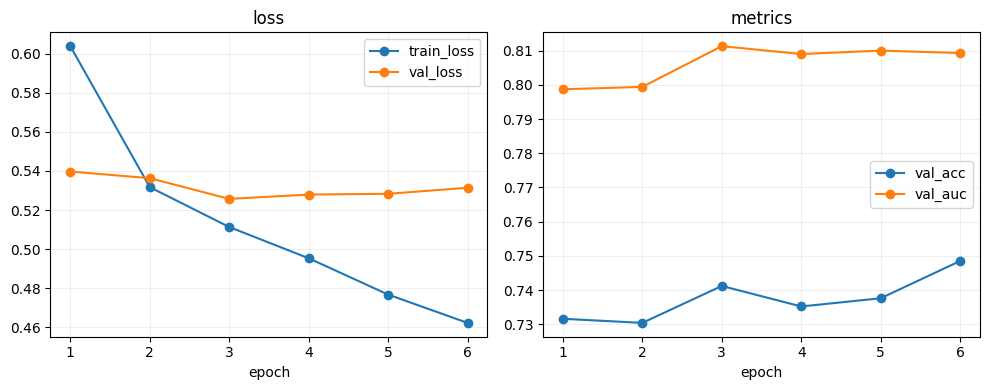

In [4]:
from typing import Dict, List

def _parse_kv_line(line: str) -> Dict[str, float]:
    out: Dict[str, float] = {}
    for token in line.strip().split():
        if "=" not in token:
            continue
        k, v = token.split("=", 1)
        try:
            out[k] = float(v)
        except ValueError:
            continue
    return out

def parse_training_log(text: str) -> Dict[str, List[float]]:
    rows: List[Dict[str, float]] = []
    for raw in text.splitlines():
        if not raw.strip().startswith("epoch="):
            continue
        rows.append(_parse_kv_line(raw))
    if not rows:
        raise ValueError("没有解析到 epoch=... 的日志行。")
    keys = sorted({k for r in rows for k in r.keys()})
    series: Dict[str, List[float]] = {k: [] for k in keys}
    for r in rows:
        for k in keys:
            series[k].append(r.get(k, float("nan")))
    return series

series = parse_training_log(log_text)
try:
    import matplotlib.pyplot as plt
    epochs = series.get("epoch") or list(range(1, len(next(iter(series.values()))) + 1))
    plt.figure(figsize=(10, 4))
    ax1 = plt.subplot(1, 2, 1)
    for k in ["train_loss", "val_loss", "loss"]:
        if k in series:
            ax1.plot(epochs, series[k], marker="o", label=k)
    ax1.set_title("loss")
    ax1.set_xlabel("epoch")
    ax1.grid(True, alpha=0.2)
    ax1.legend()

    ax2 = plt.subplot(1, 2, 2)
    for k in ["val_acc", "acc", "val_auc", "auc"]:
        if k in series:
            ax2.plot(epochs, series[k], marker="o", label=k)
    ax2.set_title("metrics")
    ax2.set_xlabel("epoch")
    ax2.grid(True, alpha=0.2)
    ax2.legend()
    plt.tight_layout()
    plt.show()
except Exception:
    keys = [k for k in ["epoch", "train_loss", "val_loss", "val_acc", "val_auc"] if k in series]
    print("matplotlib 不可用，改为输出表格：")
    n = len(series[keys[0]]) if keys else 0
    for i in range(n):
        row = {k: series[k][i] for k in keys}
        print(row)
